# 🌾 CropNexus — Notebook 1: Data Understanding & Exploratory Data Analysis

This notebook looks at the raw data before we build anything. We do this first because you must understand your data well before you can clean it or train a model on it.

## 1. Installing Packages
We install these libraries because our code needs them to run. This step is only needed once on a new computer.

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib -q

## 2. Import Libraries
We import the libraries here so we can use their tools (like tables and charts) in the rest of the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

## 3. Load Dataset
We load the CSV file into a table (DataFrame) because that is the easiest way to view and work with the data in Python.

In [3]:
df = pd.read_csv("../data/raw/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 4. Understanding Dataset
We check the shape, column types, and stats to quickly learn what the data looks like and to catch any obvious problems early.

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (2200, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


In [7]:
print("Number of crop classes:", df['label'].nunique())
df['label'].value_counts()

Number of crop classes: 22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## 5. Exploratory Data Analysis (EDA)
We explore the data with charts because pictures make patterns and problems easier to spot than plain numbers.

### 5.1 Class balance
We check how many rows each crop has to make sure no crop is over- or under-represented, which could confuse the model.

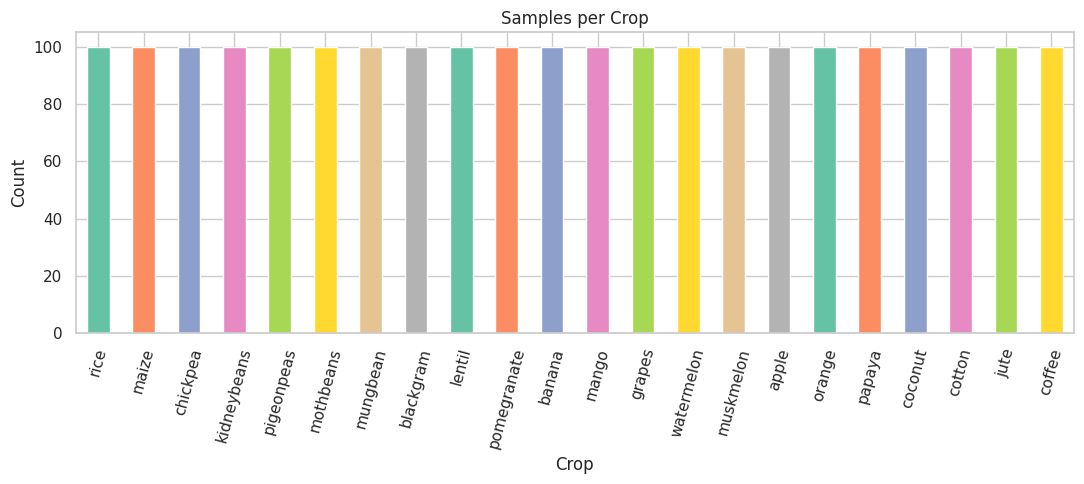

In [8]:
plt.figure(figsize=(11, 5))
df['label'].value_counts().plot(kind='bar', color=sns.color_palette("Set2"))
plt.title("Samples per Crop")
plt.ylabel("Count")
plt.xlabel("Crop")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("../data/processed/eda_class_balance.png", dpi=110)
plt.show()

### 5.2 Feature distributions
We plot each feature's spread because knowing the normal range of values helps us catch outliers or errors.

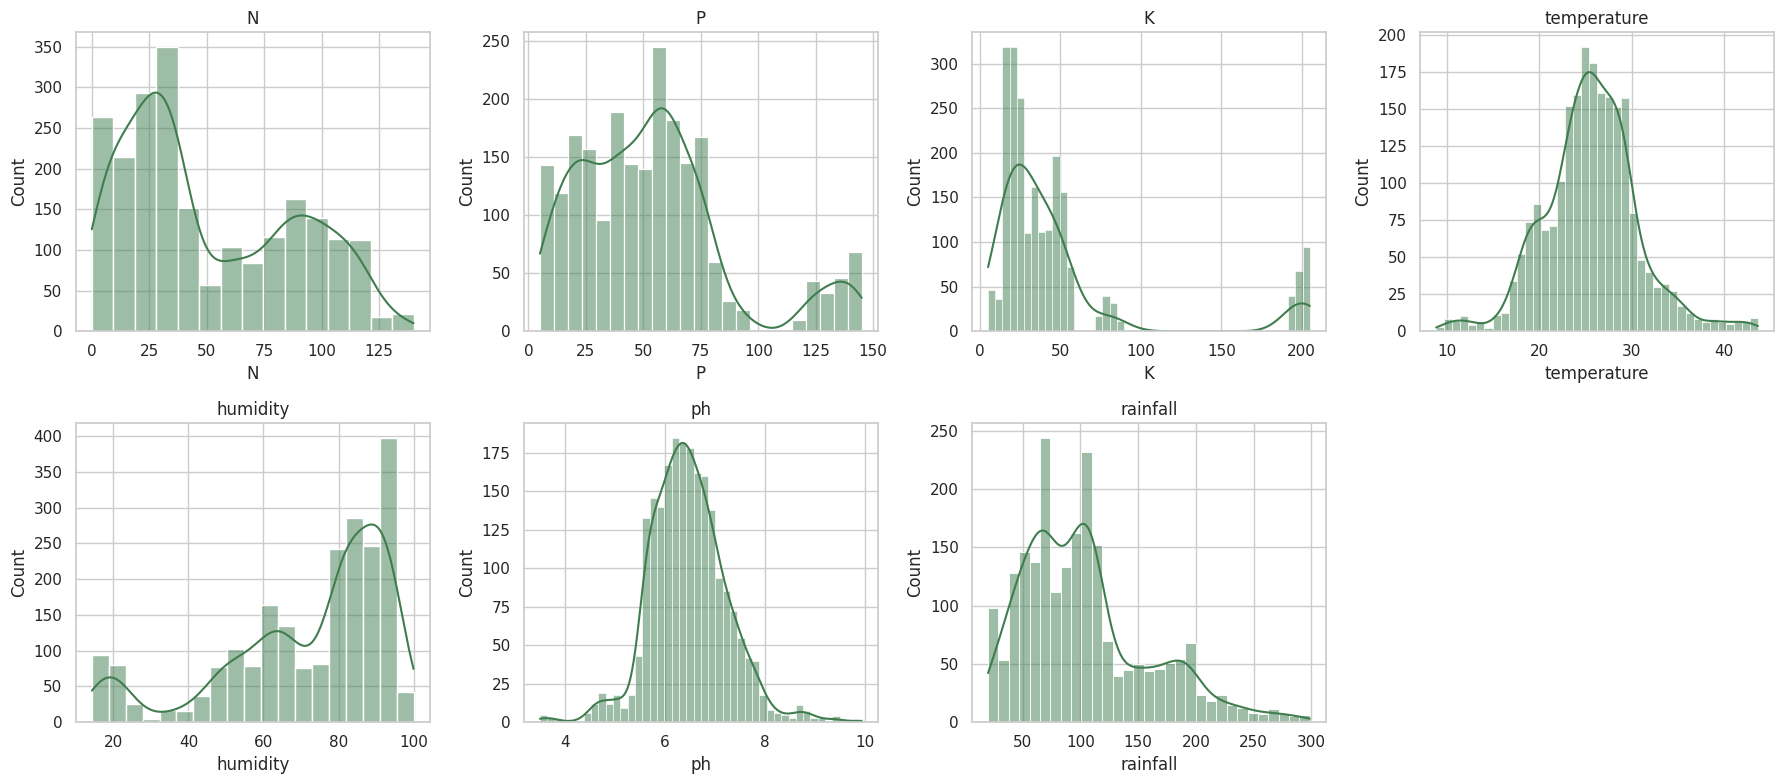

In [9]:
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#3F7D4F")
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig("../data/processed/eda_distributions.png", dpi=110)
plt.show()

### 5.3 Correlation heatmap
We check how features relate to each other so we know which ones move together and which give unique information.

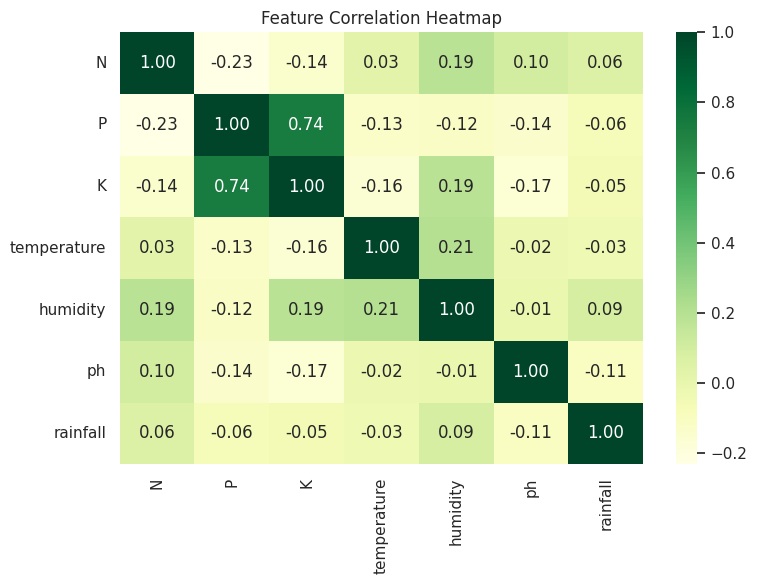

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="YlGn", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../data/processed/eda_correlation.png", dpi=110)
plt.show()

### 5.4 Nutrient requirement per crop
We compare N, P, K needs across crops because different nutrient levels are exactly what helps the model tell crops apart.

/tmp/ipykernel_601/3839987361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=ax, palette="Set2")
/tmp/ipykernel_601/3839987361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=ax, palette="Set2")


/tmp/ipykernel_601/3839987361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=ax, palette="Set2")


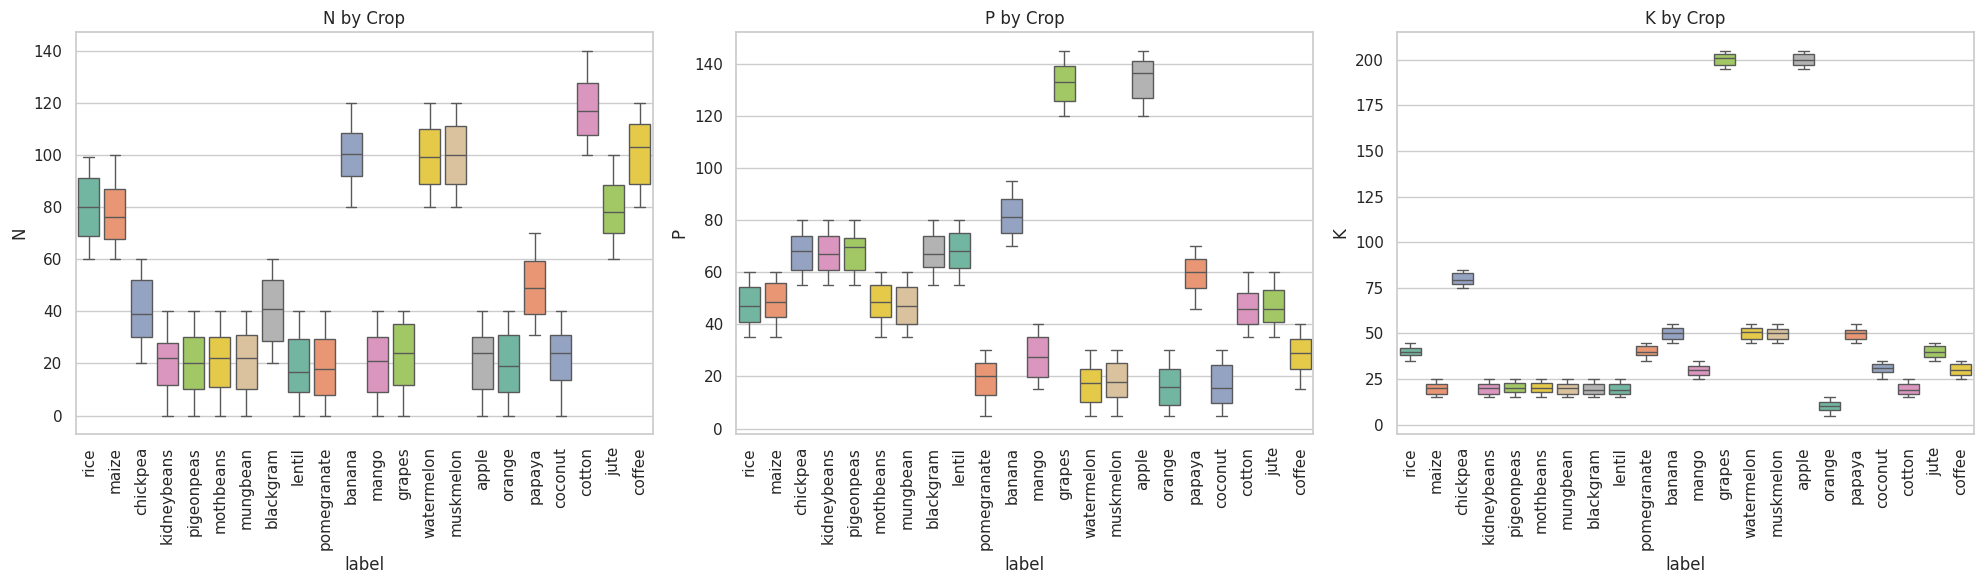

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, ['N', 'P', 'K']):
    sns.boxplot(data=df, x='label', y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col} by Crop")
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig("../data/processed/eda_npk_boxplots.png", dpi=110)
plt.show()

### 5.5 Temperature vs. Rainfall by crop cluster
We plot temperature against rainfall to see if crops naturally group together by climate, which is useful signal for the model.

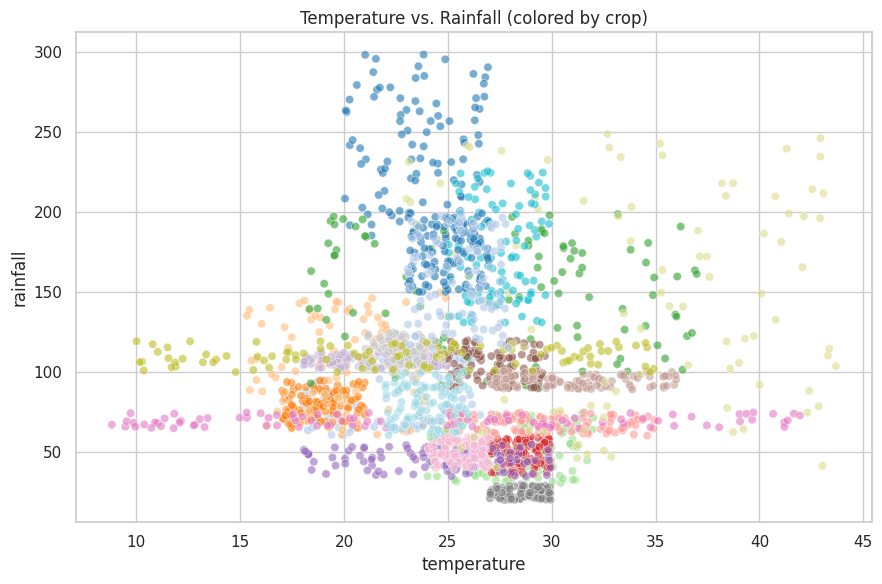

In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='temperature', y='rainfall', hue='label', legend=False, alpha=0.6, palette="tab20")
plt.title("Temperature vs. Rainfall (colored by crop)")
plt.tight_layout()
plt.savefig("../data/processed/eda_temp_rainfall.png", dpi=110)
plt.show()

## 6. Data Cleaning
We remove duplicate rows because repeated data can unfairly bias the model towards those repeated examples.

In [13]:
before = df.shape[0]
df_clean = df.drop_duplicates().reset_index(drop=True)
after = df_clean.shape[0]
print(f"Removed {before - after} duplicate row(s). Final shape: {df_clean.shape}")
df_clean.to_csv("../data/processed/crop_understood.csv", index=False)

Removed 0 duplicate row(s). Final shape: (2200, 8)
